In [ ]:
!pip install yfinance

import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.mixture import GaussianMixture

import warnings
warnings.filterwarnings("ignore")

In [ ]:
tickers = [
"AAPL","MSFT","GOOGL","AMZN","META",
"TSLA","JPM","XOM","NVDA","SPY"
]

data = yf.download(
    tickers,
    start="2006-01-01",
    end="2023-12-31",
    auto_adjust=True
)

data = data["Close"]

data.head()

[*********************100%***********************]  10 of 10 completed


Ticker,AAPL,AMZN,GOOGL,JPM,META,MSFT,NVDA,SPY,TSLA,XOM
Date,,,,,,,,,,
2006-01-03,2.239734,2.3790,10.802360,23.754637,NaN,18.672438,0.292012,87.463249,NaN,29.426702
2006-01-04,2.246327,2.3625,11.050808,23.617531,NaN,18.762880,0.300187,87.877449,NaN,29.477037
2006-01-05,2.228650,2.3825,11.199728,23.689068,NaN,18.776794,0.306986,87.932671,NaN,29.331070
2006-01-06,2.286176,2.3935,11.557630,23.855974,NaN,18.721138,0.312029,88.664398,NaN,29.909838
2006-01-09,2.278687,2.3540,11.588405,24.243429,NaN,18.686356,0.320739,88.892227,NaN,29.894749


In [ ]:
returns = data.pct_change().dropna()

returns.head()

Ticker,AAPL,AMZN,GOOGL,JPM,META,MSFT,NVDA,SPY,TSLA,XOM
Date,,,,,,,,,,
2012-05-21,0.058261,0.019921,0.022835,-0.029263,-0.109862,0.016399,0.017384,0.017188,0.043904,0.006996
2012-05-22,-0.007680,-0.012746,-0.021674,0.046140,-0.089039,0.000336,-0.012205,0.001743,0.070559,-0.001097
2012-05-23,0.024400,0.009056,0.014414,0.007351,0.032258,-0.021841,0.024712,0.000530,0.007143,0.001098
2012-05-24,-0.009184,-0.009389,-0.009516,-0.008465,0.032187,-0.001375,-0.026527,0.001966,-0.023855,0.006948
2012-05-25,-0.005360,-0.010918,-0.020094,-0.013836,-0.033908,-0.000344,0.023947,-0.003245,-0.015522,-0.006416


In [ ]:
#COMPUTING 30-DAYS VOLATILITY
volatility = returns.rolling(window=30).std().dropna()

volatility.head()

Ticker,AAPL,AMZN,GOOGL,JPM,META,MSFT,NVDA,SPY,TSLA,XOM
Date,,,,,,,,,,
2012-07-02,0.016606,0.015365,0.014398,0.022879,0.044013,0.016119,0.027504,0.011801,0.035779,0.014050
2012-07-03,0.013161,0.015008,0.013929,0.022092,0.039540,0.015905,0.027694,0.011483,0.034989,0.014121
2012-07-05,0.013308,0.014945,0.013647,0.022115,0.035999,0.015915,0.027654,0.011537,0.032728,0.014231
2012-07-06,0.012794,0.015006,0.013681,0.022242,0.035548,0.015682,0.027695,0.011706,0.032743,0.014361
2012-07-09,0.012767,0.014874,0.013592,0.022184,0.035137,0.015737,0.027316,0.011712,0.032532,0.014564


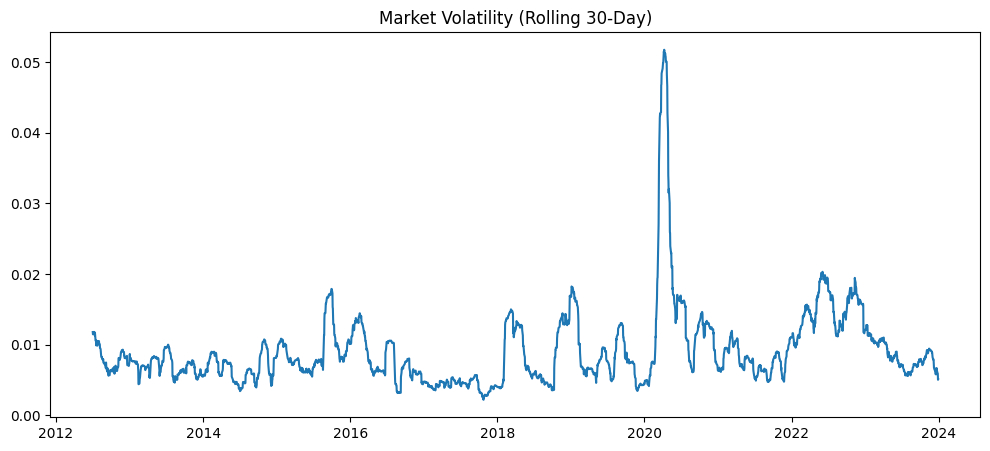

In [ ]:
#MARKET VOLATILITY PROXY
market_vol = volatility["SPY"]

plt.figure(figsize=(12,5))
plt.plot(market_vol)
plt.title("Market Volatility (Rolling 30-Day)")
plt.show()

In [ ]:
#DATA PREPARATION FOR CLUSTERING
X = market_vol.values.reshape(-1,1)

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [ ]:
#K-MEANS VOLATILITY REGIME CLUSTERING
kmeans = KMeans(n_clusters=3,random_state=42)
clusters = kmeans.fit_predict(X_scaled)

regime_data = pd.DataFrame({
    "Volatility": market_vol.values,
    "Regime": clusters
}, index=market_vol.index)

regime_data.head()

,Volatility,Regime
Date,,
2012-07-02,0.011801,2
2012-07-03,0.011483,2
2012-07-05,0.011537,2
2012-07-06,0.011706,2
2012-07-09,0.011712,2


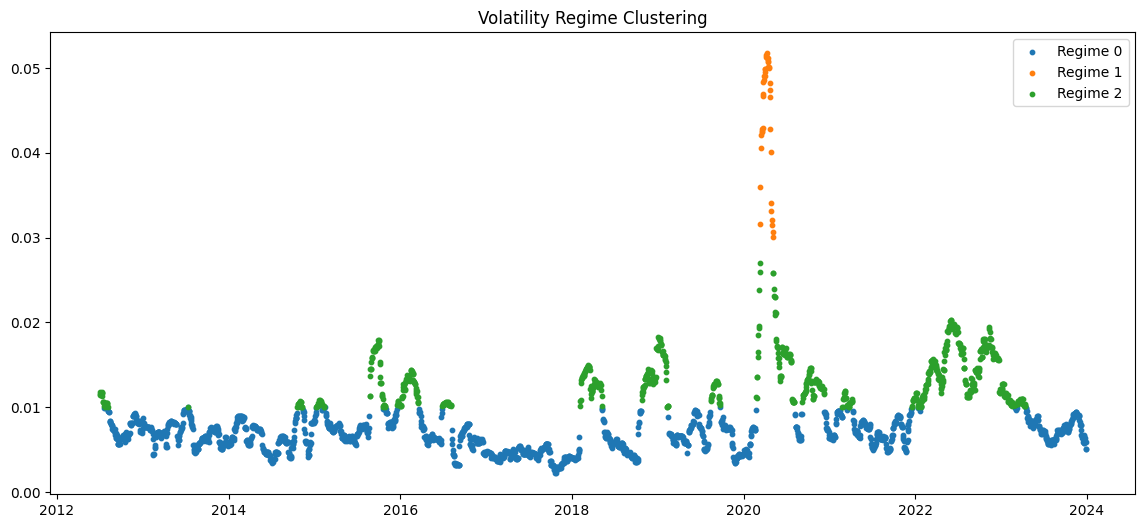

In [ ]:
#VISUALIZE VOLATILITY REGIME
plt.figure(figsize=(14,6))

for regime in range(3):
    plt.scatter(
        regime_data.index[regime_data.Regime==regime],
        regime_data.Volatility[regime_data.Regime==regime],
        label=f"Regime {regime}",
        s=10
    )

plt.legend()
plt.title("Volatility Regime Clustering")
plt.show()

In [ ]:
#LABEL THE REGIMES
regime_mean = regime_data.groupby("Regime").mean()

regime_order = regime_mean.sort_values("Volatility").index

mapping = {
    regime_order[0]: "Low Volatility",
    regime_order[1]: "Medium Volatility",
    regime_order[2]: "High Volatility"
}

regime_data["Regime_Label"] = regime_data["Regime"].map(mapping)

regime_data.head()

,Volatility,Regime,Regime_Label
Date,,,
2012-07-02,0.011801,2,Medium Volatility
2012-07-03,0.011483,2,Medium Volatility
2012-07-05,0.011537,2,Medium Volatility
2012-07-06,0.011706,2,Medium Volatility
2012-07-09,0.011712,2,Medium Volatility


In [ ]:
#MERGING REGIMES WITH RETURNS
returns_regime = returns.loc[regime_data.index]

returns_regime["Regime"] = regime_data["Regime_Label"]

returns_regime.head()

Ticker,AAPL,AMZN,GOOGL,JPM,META,MSFT,NVDA,SPY,TSLA,XOM,Regime
Date,,,,,,,,,,,
2012-07-02,0.014589,0.004248,0.000690,0.015393,-0.010611,-0.000981,-0.026773,0.003012,-0.028443,-0.002688,Medium Volatility
2012-07-03,0.011628,0.000916,0.012679,-0.002780,0.013975,0.006545,0.026022,0.006593,0.008552,0.011015,Medium Volatility
2012-07-05,0.017567,-0.010761,0.013763,-0.041806,0.008654,-0.001950,-0.010144,-0.004512,0.018591,-0.008229,Medium Volatility
2012-07-06,-0.006657,-0.008852,-0.016680,-0.013962,0.008262,-0.016613,-0.019034,-0.009503,-0.007685,-0.008999,Medium Volatility
2012-07-09,0.013221,0.000000,0.000051,0.001770,0.013867,-0.006293,-0.013433,-0.001255,0.016134,-0.013561,Medium Volatility


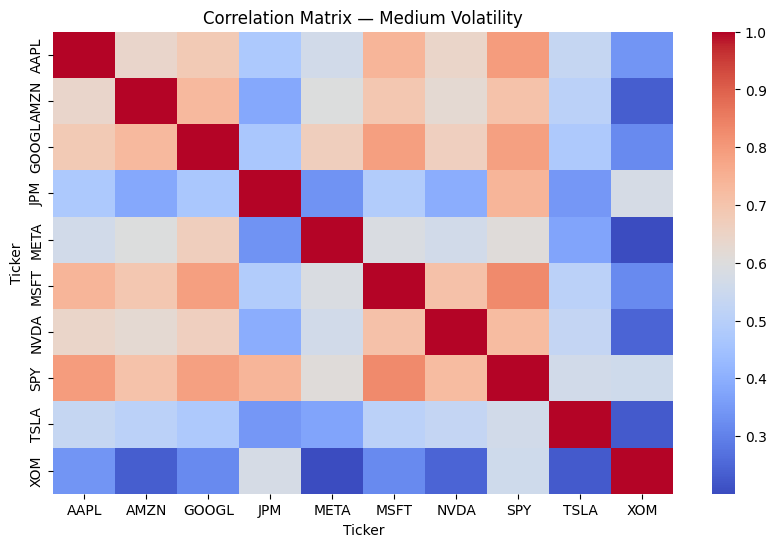

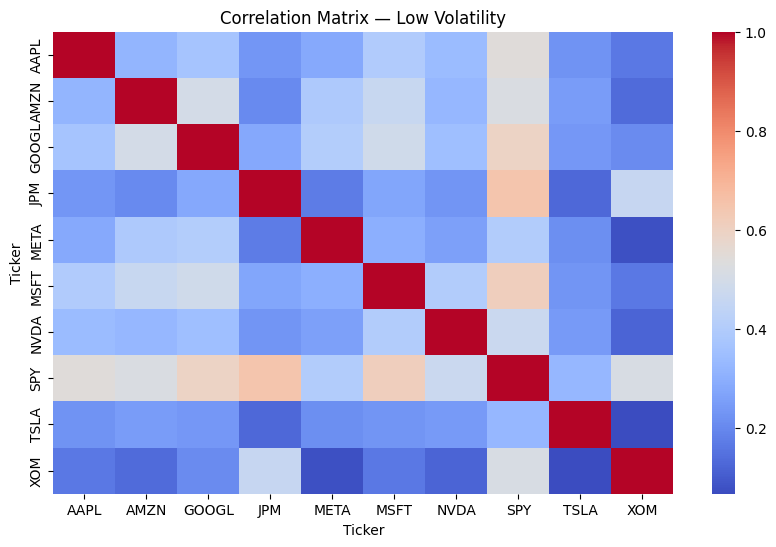

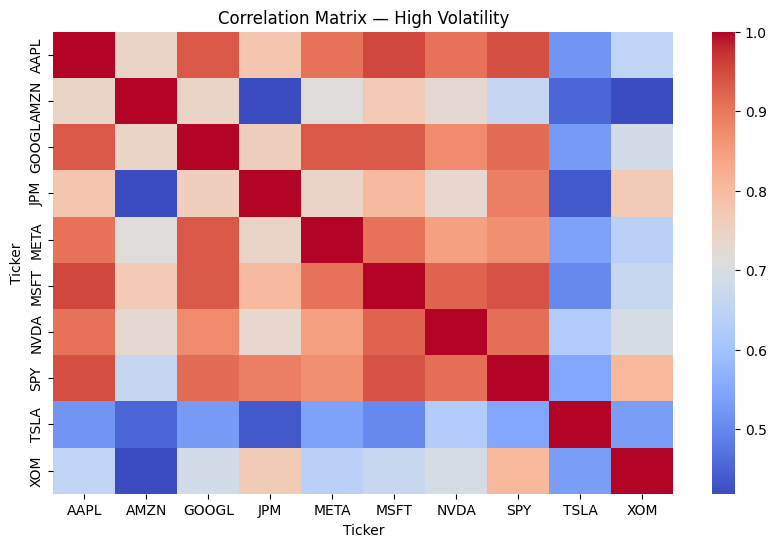

In [ ]:
#CORRELATION ANALYSIS BY REGIMES
for regime in returns_regime["Regime"].unique():

    regime_subset = returns_regime[returns_regime["Regime"]==regime].drop(columns=["Regime"])

    corr_matrix = regime_subset.corr()

    plt.figure(figsize=(10,6))
    sns.heatmap(corr_matrix,cmap="coolwarm")
    plt.title(f"Correlation Matrix — {regime}")
    plt.show()

In [ ]:
#PORTFOLIO CONSTRUCTION
weights = np.repeat(1/len(tickers),len(tickers))

portfolio_returns = returns.dot(weights)

portfolio_returns = portfolio_returns.loc[regime_data.index]

portfolio_df = pd.DataFrame({
    "Returns": portfolio_returns,
    "Regime": regime_data["Regime_Label"]
})

In [ ]:
#SHARPE REATIO BY REGIMES
results = []

for regime in portfolio_df["Regime"].unique():

    subset = portfolio_df[portfolio_df["Regime"]==regime]

    mean_return = subset["Returns"].mean()
    std_return = subset["Returns"].std()

    sharpe = mean_return/std_return

    results.append([regime,mean_return,std_return,sharpe])

results_df = pd.DataFrame(
    results,
    columns=["Regime","Mean Return","Volatility","Sharpe Ratio"]
)

results_df

,Regime,Mean Return,Volatility,Sharpe Ratio
0,Medium Volatility,0.000719,0.019027,0.037767
1,Low Volatility,0.001249,0.010065,0.124109
2,High Volatility,0.004706,0.045735,0.102899


In [ ]:
#VALUE AT RISK (VaR)
VaR_results = []

for regime in portfolio_df["Regime"].unique():

    subset = portfolio_df[portfolio_df["Regime"]==regime]

    VaR = np.percentile(subset["Returns"],5)

    VaR_results.append([regime,VaR])

VaR_df = pd.DataFrame(VaR_results,columns=["Regime","VaR (95%)"])

VaR_df

,Regime,VaR (95%)
0,Medium Volatility,-0.030940
1,Low Volatility,-0.016164
2,High Volatility,-0.063791


In [ ]:
#DISVERSIFICATION MEASURE
variance_results = []

for regime in portfolio_df["Regime"].unique():

    subset = returns_regime[returns_regime["Regime"]==regime].drop(columns=["Regime"])

    cov_matrix = subset.cov()

    portfolio_var = np.dot(weights.T,np.dot(cov_matrix,weights))

    variance_results.append([regime,portfolio_var])

variance_df = pd.DataFrame(
    variance_results,
    columns=["Regime","Portfolio Variance"]
)

variance_df

,Regime,Portfolio Variance
0,Medium Volatility,0.000362
1,Low Volatility,0.000101
2,High Volatility,0.002092


In [ ]:
#COMPARISON TABLE
final_results = results_df.merge(VaR_df,on="Regime")
final_results = final_results.merge(variance_df,on="Regime")

final_results

,Regime,Mean Return,Volatility,Sharpe Ratio,VaR (95%),Portfolio Variance
0,Medium Volatility,0.000719,0.019027,0.037767,-0.030940,0.000362
1,Low Volatility,0.001249,0.010065,0.124109,-0.016164,0.000101
2,High Volatility,0.004706,0.045735,0.102899,-0.063791,0.002092


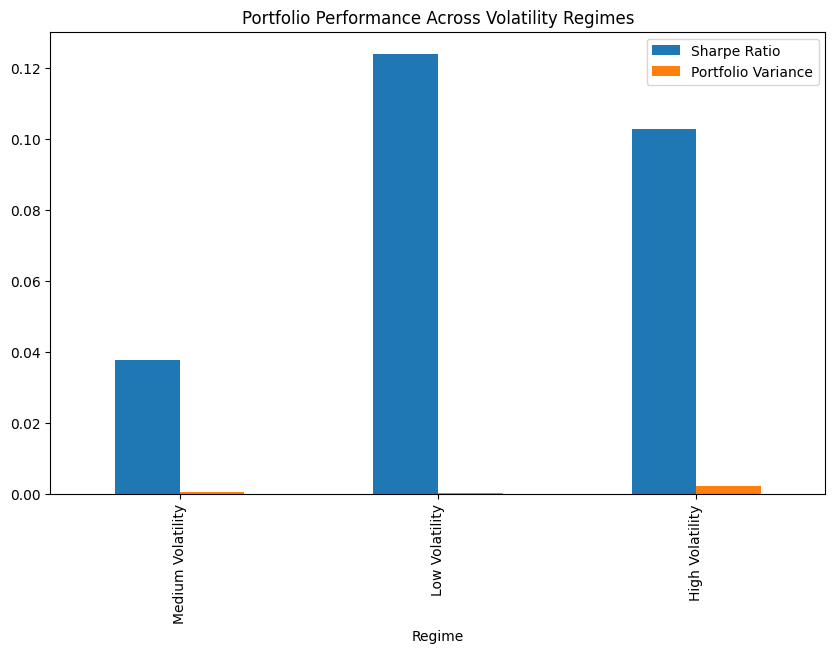

In [ ]:
#VISUALIZATION OF REGIME PERFORMANCE
final_results.set_index("Regime")[["Sharpe Ratio","Portfolio Variance"]].plot(
    kind="bar",
    figsize=(10,6)
)

plt.title("Portfolio Performance Across Volatility Regimes")
plt.show()